# EV Charging Infrastructure Planning & Demand Prediction

## Notebook 14 : Customer Recommendation Engine

### Business Objective

The objective of this notebook is to recommend the best EV charging station for customers based on charging station availability, waiting time, charger type, customer rating, and operational status.

In [14]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [15]:
customer = pd.read_csv("../data/processed/master_dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [16]:
customer = customer[
[
    "State",
    "City",
    "Station_Name",
    "Station_Type",
    "Charger_Type",
    "Status",
    "Customer_Rating",
    "Avg_Wait_Time_Min",
    "Queue_Length",
    "Total_Chargers",
    "Fast_Chargers",
    "Parking_Capacity"
]]

In [17]:
customer = (
    customer
    .groupby(
        [
            "State",
            "City",
            "Station_Name",
            "Station_Type",
            "Charger_Type"
        ]
    )
    .agg({
        "Customer_Rating": "mean",
        "Avg_Wait_Time_Min": "mean",
        "Queue_Length": "mean",
        "Total_Chargers": "max",
        "Fast_Chargers": "max",
        "Parking_Capacity": "max",
        "Status": "first"
    })
    .reset_index()
)

In [18]:
customer = customer.dropna(
    subset=[
        "Station_Name",
        "Avg_Wait_Time_Min"
    ]
)

customer.reset_index(drop=True, inplace=True)

In [24]:
customer["Recommendation_Score"] = (

    customer["Customer_Rating"] * 30 +

    (30 - customer["Avg_Wait_Time_Min"]) * 2 +

    customer["Fast_Chargers"] * 3 +

    customer["Total_Chargers"] +

    customer["Parking_Capacity"] * 0.5

)

In [25]:
customer["Recommendation"] = np.select(
    [
        customer["Recommendation_Score"] >= 220,
        customer["Recommendation_Score"] >= 170
    ],
    [
        "Highly Recommended",
        "Recommended"
    ],
    default="Average"
)

In [21]:
customer = customer.sort_values(

by="Recommendation_Score",

ascending=False

)

In [26]:
customer_output = customer[
[
    "State",
    "City",
    "Station_Name",
    "Station_Type",
    "Charger_Type",
    "Status",
    "Customer_Rating",
    "Avg_Wait_Time_Min",
    "Queue_Length",
    "Recommendation",
    "Recommendation_Score"
]]

In [28]:
customer_output = customer_output.sort_values(
    by="Recommendation_Score",
    ascending=False
).reset_index(drop=True)

In [29]:
customer_output.head(20)

,State,City,Station_Name,Station_Type,Charger_Type,Status,Customer_Rating,Avg_Wait_Time_Min,Queue_Length,Recommendation,Recommendation_Score
0,Uttar Pradesh,Lucknow,Lucknow Ev Hub 3,Highway,Dc,Active,4.250000,17.816667,5.500000,Highly Recommended,236.866667
1,Kerala,Thiruvananthapuram,Thiruvananthapuram Ev Hub 1,Highway,Dc,Active,4.228333,17.566667,5.400000,Highly Recommended,234.716667
2,Gujarat,Ahmedabad,Ahmedabad Ev Hub 2,Private,Ac,Active,4.205000,18.400000,5.500000,Highly Recommended,231.350000
3,Gujarat,Ahmedabad,Ahmedabad Ev Hub 1,Highway,Dc,Active,4.171667,17.916667,5.700000,Highly Recommended,228.816667
4,Maharashtra,Nagpur,Nagpur Ev Hub 2,Public,Mixed,Active,4.223333,17.600000,5.350000,Highly Recommended,227.000000
5,Telangana,Nizamabad,Nizamabad Ev Hub 2,Private,Mixed,Active,4.251667,17.683333,5.650000,Highly Recommended,222.683333
6,Maharashtra,Mumbai,Mumbai Ev Hub 2,Private,Ac,Active,4.103333,17.216667,5.350000,Highly Recommended,221.666667
7,Rajasthan,Udaipur,Udaipur Ev Hub 3,Private,Ac,Active,4.163333,17.700000,5.300000,Highly Recommended,220.000000
8,Gujarat,Vadodara,Vadodara Ev Hub 5,Highway,Mixed,Active,4.233333,18.400000,5.883333,Recommended,218.200000
9,Uttar Pradesh,Lucknow,Lucknow Ev Hub 2,Private,Ac,Active,4.206667,16.783333,5.050000,Recommended,217.633333


In [30]:
print(customer_output["Recommendation"].value_counts())

Recommendation
Recommended           108
Highly Recommended      8
Average                 6
Name: count, dtype: int64


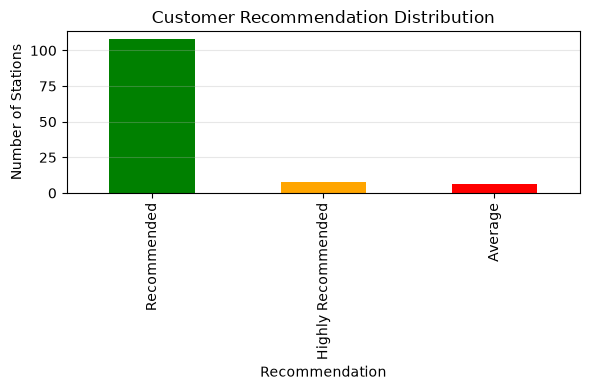

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

customer_output["Recommendation"].value_counts().plot(
    kind="bar",
    color=["green", "orange", "red"]
)

plt.title("Customer Recommendation Distribution")
plt.xlabel("Recommendation")
plt.ylabel("Number of Stations")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
customer_output.to_csv(
    "../data/processed/customer_recommendation.csv",
    index=False
)

print("Customer Recommendation Dataset Saved Successfully.")

Customer Recommendation Dataset Saved Successfully.
